In [ ]:
############ LOAD in packages ################
import sys
import os
import pandas as pd
import numpy as np
import importlib
from fastdtw import dtw
import datetime as dt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from tslearn.metrics import cdist_dtw
from sklearn.cluster import DBSCAN
from tslearn.utils import to_time_series_dataset
import pandas as pd
import plotly.express as px

# Get the absolute path of the project root
project_root = os.getcwd()
# Define data directory
brighten_dir = os.path.join(project_root, 'BRIGHTEN_data')

# Add project root to sys.path
sys.path.append(project_root)

# Import and reload custom scripts
from scripts import preprocessing as pre
from scripts import visualization as vis
from scripts import feature_selection as fs
from scripts import clustering as cl
importlib.reload(pre)
importlib.reload(vis)
importlib.reload(fs)
importlib.reload(cl)


################ DEFINE column variables from data ###################
from scripts.variables import id_columns, daily_cols_v1, daily_v2_common 
from scripts.variables import phq2_cols, phq9_cols, weekly_cols, passive_cols
from scripts.variables import df_names, df_names_with_mis

############# Load in dfs scaled ###############
dfs = {}
for name in df_names:
    for split in ['trainval']:
        dfs[name] = pd.read_csv(os.path.join(brighten_dir, f'{name}_{split}_imputed.csv'))


# helper funcs
def drop_col_outliers_iqr(df, column, factor=1.5):
    """
    Removes rows in which 'column' has values outside the IQR range.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

def drop_outliers_iqr(df, columns, factor=1.5):
    """
    Sets to NaN values outside the IQR range in columns which are in list 'columns'.
    """
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        df.loc[outliers, col] = np.nan
    return df


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_76669/358553173.py:44: DtypeWarning: Columns (111) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[name] = pd.read_csv(os.path.join(brighten_dir, f'{name}_{split}_imputed.csv'))


In [ ]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

mobility_cols = ['location_variance_hr','hours_active_hr','hours_walking_hr','mobility','mobility_radius']

target = 'phq9_sum'
colors = {
    0: "rgb(173, 216, 230)",  # LightBlue
    1: "rgb(100, 149, 237)",  # CornflowerBlue
    2: "rgb(65, 105, 225)",   # RoyalBlue
    3: "rgb(0, 0, 205)",      # MediumBlue
    4: "rgb(0, 0, 139)"       # DarkBlue
}

for var in mobility_cols:
    for name in ['v1_week','v2_week']:
        df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
        df[f'{target}_cat'] = pd.cut(df[target], bins=5)
        bin_labels = df[f'{target}_cat'].cat.categories  
        bin_sorted = bin_labels.sort_values()
        if var in df.columns and target in df.columns:
            df[var] = [float(i) for i in df[var].to_list()]
            df = df.copy()
            df_clean = drop_col_outliers_iqr(df, var)
            df_sorted = df_clean.sort_values(by=f'{target}_cat')
            #display(df_sorted)
            color_map = {
                bin_labels[0]: colors[0],
                bin_labels[1]: colors[1],
                bin_labels[2]: colors[2],
                bin_labels[3]: colors[3],
                bin_labels[4]: colors[4],
            }
            # labels_map = {
            #     bin_labels[0]: "low",
            #     bin_labels[1]: "medium low",
            #     bin_labels[2]: "medium",
            #     bin_labels[3]: "medium high",
            #     bin_labels[4]: "high",
            # }                                        


            fig = px.histogram(df_sorted, x=var, y='num_id', color=f'{target}_cat', color_discrete_map=color_map,
                                    category_orders={f"{target}_cat": [1, 2, 3, 4, 5]},# labels=labels_map,
                                    title=f'{var} histogram colored by {target} for {name}')
            fig.show()
        

----------------v1_day----------------
Var df:
    num_id  week  mobility
0     1.0     0  1.647668
1     1.0     0  2.190466
2     1.0     0  1.909405
3     1.0     0  2.106258
4     1.0     0  1.774997


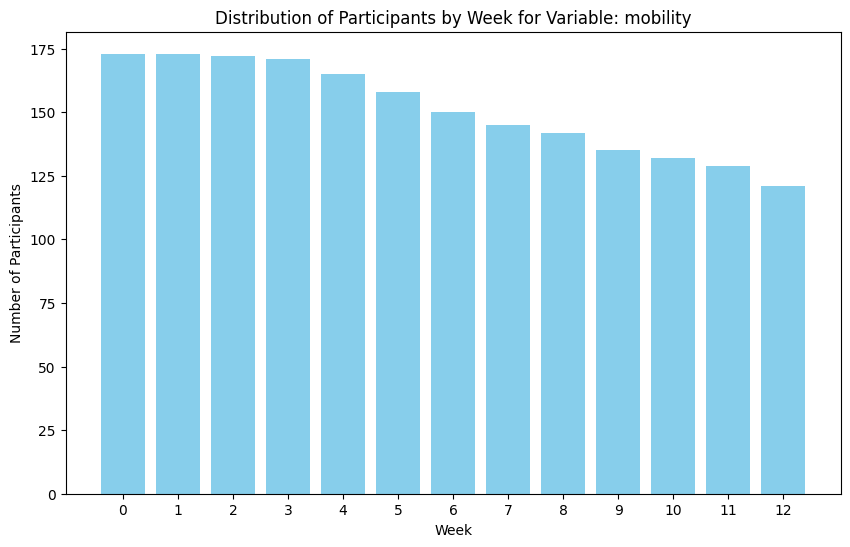

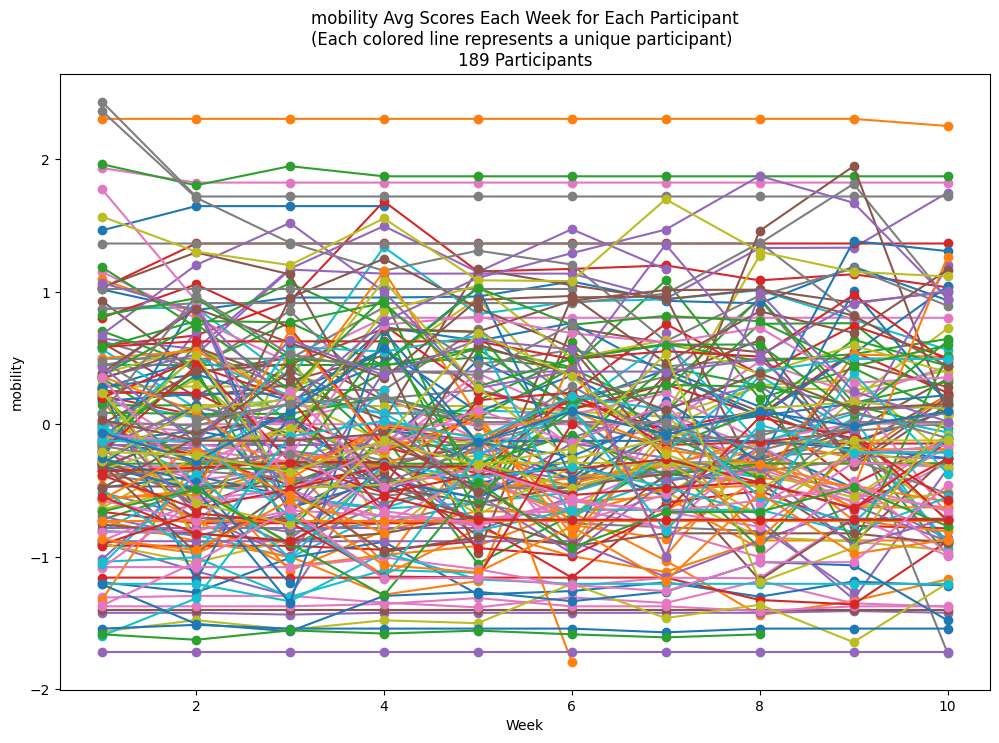

Pivot df:


,num_id,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.0,1.830460,1.464876,1.647668,1.647668,1.647668,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,13.0,2.306195,2.306195,2.306195,2.306195,2.306195,2.306195,2.306195,2.306195,2.306195,2.306195,2.252733,2.327549,2.530955
2,14.0,0.448694,0.448694,0.448694,0.448694,0.448694,0.507024,0.421960,0.094727,0.759566,0.764270,0.187599,0.229286,1.683646
3,17.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,29.0,-0.693058,-0.892458,-1.108171,-1.294702,-0.215995,-0.799126,-0.548512,0.689859,-0.722197,-1.319589,-0.335332,-1.077418,-0.693058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
184,1911.0,0.841802,0.436437,-0.138178,0.639751,0.370815,0.636678,0.566546,-1.000300,0.992077,0.248984,0.021802,0.293969,0.214681
185,1912.0,-0.000044,0.034216,-0.122826,-0.122826,-0.070608,-0.510208,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
186,1913.0,-1.250535,-1.366726,-1.040035,-0.639286,-1.164150,-1.156710,-1.212629,-1.258655,-1.040035,-1.040035,-0.459135,-0.902959,0.000000
187,1916.0,-0.199237,0.480034,0.039823,0.150422,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


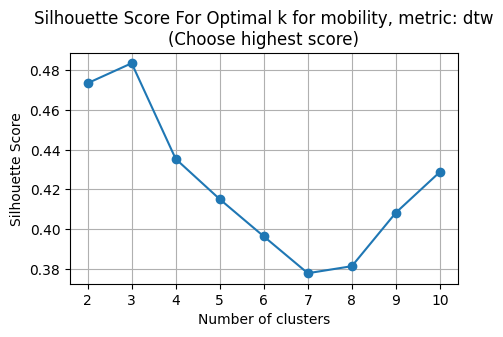

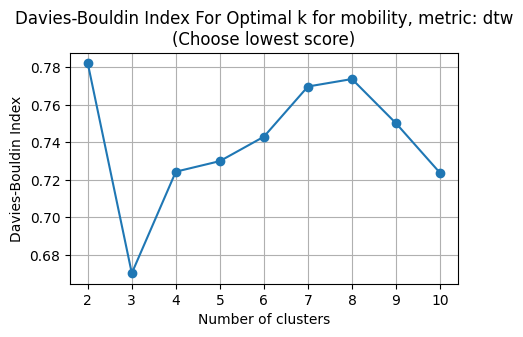

In [ ]:
##### Cluster independent variables into high/low clusters
# K means clustering
importlib.reload(cl)
### MULTI-TIME DTW DISTANCE MATRIX 
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os

print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# Step 0: Choose a Y-variable to cluster & import data
cluster_var = 'mobility' #choose y_col
v1_day_weeks = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
v1_week_weeks = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0]

for name in ['v1_day']:
    print(f'----------------{name}----------------')
    df = pd.read_csv(os.path.join(brighten_dir, f'{name}_{split}_imputed.csv'))
    # Display/chart cluster data
    if 'v1_day' in name:
        required_weeks = v1_day_weeks
    if 'v1_week' in name:
        required_weeks = v1_week_weeks
    pivot_df = cl.process_cluster_data(df, cluster_var, required_weeks)
    print('Pivot df:')
    display(pivot_df)
    # Now do cluster analysis for different clusters' scores
    metric='dtw'
    distance_matrix, embedding, results = cl.cluster_distance_analysis(pivot_df, required_weeks, cluster_var, n_clusters_range=range(1, 11), metric=metric)
    pivot_df.to_csv(os.path.join(brighten_dir, 'graphing', f'{name}_{cluster_var}.csv'), index=False)
    distance_matrix = pd.DataFrame(distance_matrix)
    distance_matrix.to_csv(os.path.join(brighten_dir, 'clustering', f'{name}_{metric}-distanceMatrix_{cluster_var}.csv'), index=False)



/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/clustering.py:393: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/clustering.py:394: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/clustering.py:395: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/clustering.py:396: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



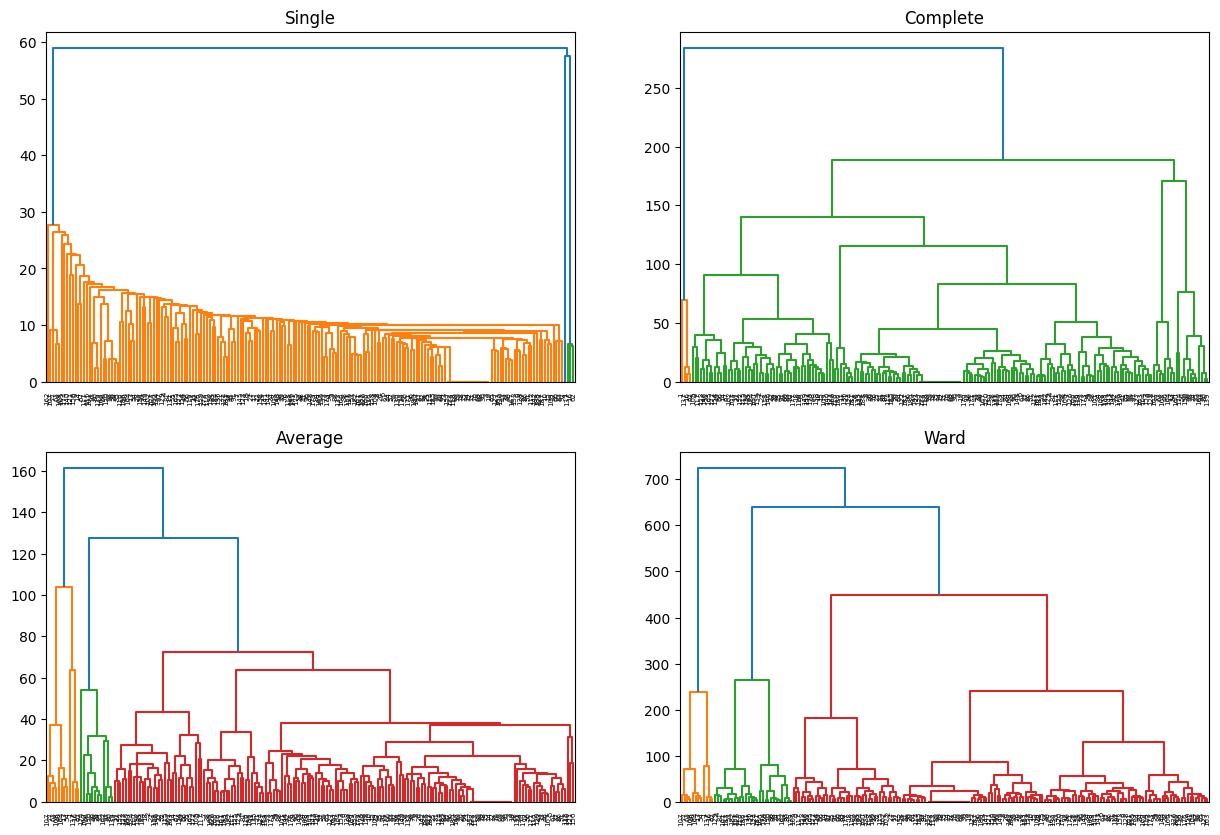

In [ ]:
### Run cluster analysis using bootstrapping and Jaccard similarity index
distance_matrix= pd.read_csv(os.path.join(brighten_dir, 'clustering', f'{name}_{metric}-distanceMatrix_{cluster_var}.csv'))
distance_matrix = distance_matrix.loc[:, ~distance_matrix.columns.str.contains('Unnamed')]
X = 1 - distance_matrix  # Convert similarity to distance if needed
X = X.values if isinstance(X, pd.DataFrame) else X

# Plot dendrogram
cl.hierarchical_agg_plot(distance_matrix)

# Run stability assessment
# kmeans_results = cl.cluster_stability_analysis(X, method='kmeans', max_k=10, n_bootstraps=1000)
# agg_results = cl.cluster_stability_analysis(X, method='agg', max_k=10, n_bootstraps=1000)
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))


In [ ]:
kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df = kmeans_results_df
kmeans_long = kmeans_results_df.reset_index().melt(id_vars='index', var_name='n_clusters', value_name='jac_score')
fig=px.scatter(kmeans_long, x='n_clusters', y='jac_score', color='jac_score', title='Jaccard Similarity Index of N Clusters with KMeans', subtitle='1000 Iterations')
fig.show()

# avg_agg = []
# for key in agg_results:
#     avg_agg.append(['agg', key, round(sum(agg_results[key])/len(agg_results[key]), 3)])
# avg_agg_df = pd.DataFrame(avg_agg, columns=['method','key','jac_score'])
agg_results_df = pd.DataFrame(agg_results)
agg_long = agg_results_df.reset_index().melt(id_vars='index', var_name='n_clusters', value_name='jac_score')
fig=px.scatter(agg_long, x='n_clusters', y='jac_score', color='jac_score', title='Jaccard Similarity Index of N Clusters with Hierarchical Agg. Clustering', subtitle='1000 Iterations')
fig.show()



In [ ]:
######### KMeans CLUSTERING for variable responses 
import plotly.express as px
import matplotlib.pyplot as plt
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# Step 1: Perform KMeans clustering
# for cluster: mobility
cluster_var = 'mobility'
cluster_label = cluster_var + "_cluster"
metric='dtw'
v1_day_weeks = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]
v1_week_weeks = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 12.0]

for name in ['v1_day']:

    # 1: Set variables
    pivot_df = pd.read_csv(os.path.join(brighten_dir, 'graphing', f'{name}_{cluster_var}.csv'))
    distance_matrix= pd.read_csv(os.path.join(brighten_dir, 'clustering', f'{name}_{metric}-distanceMatrix_{cluster_var}.csv'))
    required_weeks = [str(week) for week in v1_day_weeks] # make sure numbers are strings
    n_clusters=2

    # 2: Fit kmeans labels 
    kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(distance_matrix)

    # Step 3: Add cluster labels to df
    pivot_df[cluster_label] = kmeans.labels_
    pivot_df = pivot_df.loc[:, ~pivot_df.columns.str.contains('^Unnamed')]
    #display(pivot_df[required_weeks])

    # Step 4: Visualize the clusters
    colors = ['red', 'green', 'pink', 'yellow', 'orange', 'brown', 'black']
    graph_df = pivot_df.melt(id_vars=['num_id',cluster_label], value_vars=pivot_df[required_weeks], value_name=cluster_var)
    display(graph_df)

    # Visualize clusters in subplots
    fig, axs = plt.subplots(ncols=2, nrows=n_clusters/2, figsize=(10, 10), sharey='all',
                        layout="constrained")
    axs = axs.flatten()  
    
    # Graph each cluster (as a different color)
    for i, cluster in enumerate(sorted(set(kmeans.labels_))): 
        # Creating a new fig for each cluster
        ax = axs[i]
        cluster_df = graph_df[graph_df[cluster_label] == cluster]
        cluster_data = pivot_df[pivot_df[cluster_label]== cluster]
        # Looping over each subject 
        for sub in cluster_df['num_id'].unique():
            sub_df = cluster_df[cluster_df['num_id'] == sub]
            #Plotting each subject's trajectory over the weeks
            ax.plot(sub_df['variable'], sub_df[cluster_var], color=colors[i])
        avg_line = cluster_data[required_weeks].mean(axis=0)  # Mean across rows for each week
        std = cluster_data[required_weeks].std(axis=0)
        low_std = avg_line - std
        high_std = avg_line + std
        ax.plot(range(1, len(avg_line) + 1), avg_line, color='black', linewidth=2, label='Average')
        ax.plot(range(1, len(low_std) + 1), low_std, color='grey', linewidth=2, label='1-Stdev Below')
        ax.plot(range(1, len(high_std) + 1), high_std, color='grey', linewidth=2, label='1-Stdev Above')
        # Label the score at the beginning and end of the average line
        for line in [avg_line, low_std, high_std]:
            ax.text(1, line.iloc[0], f"{line.iloc[0]:.5f}", color='black', ha='center', va='bottom', fontweight='bold')
            ax.text(len(line), line.iloc[-1], f"{line.iloc[-1]:.5f}", color='black', ha='center', va='bottom', fontweight='bold')
        
        # Set title
        ax.set_title(f'{cluster_var} for {len(cluster_df['num_id'].unique())} subjects in cluster {cluster} (of {n_clusters})')
    plt.show()

    graph_df.to_csv(os.path.join(brighten_dir, f'{cluster_var}{n_clusters}_map.csv'), index=False)
    print(f"Cluster map for IDs to {cluster_var} ({n_clusters} clusters) saved to {cluster_var}{n_clusters}_map.csv ")



KeyError: "None of [Index(['1.0', '2.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0', '9.0', '10.0',\n       '11.0', '12.0'],\n      dtype='object')] are in the [columns]"

phq2_sum in df
263 low mobility_cluster participants
259 high mobility_cluster participants


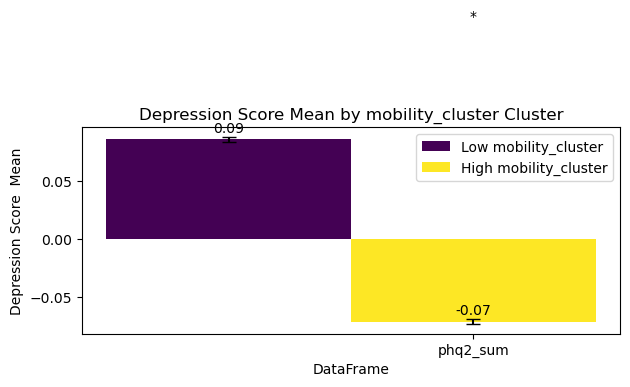

In [ ]:
#### Visualize distribution of certain variables for different clusters (KMeans)
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

cluster_label = cluster_var + "_cluster"
# Dictionary to map cluster descriptions to cluster numbers
cluster_keys = {
    "low": 0,
    # "medium_low": 3,
    # "medium": 0,
    #  "medium_high": 2,
    "high":1
    # Add more mappings as needed, e.g., "med high": 0, "med": 1, "med low": 2, "low": 3
}
n_clusters = len(cluster_keys.keys())
# Initialize the cluster df by merging the cluster id-to-cluster mapping into the large df
cluster_map = pd.read_csv(os.path.join(brighten_dir, f'{cluster_var}{n_clusters}_map.csv'))
df = pd.read_csv(os.path.join(brighten_dir, f'v1_day_res.csv'))
df_with_cluster = df.merge(cluster_map, on=['num_id'], how='outer')

# Variable to compare
y_var, y_var_name = 'phq2_sum', 'Depression Score' #mood_1, sds_1, sds_2, sds_3, phq9_sum, phq2_sum
vis.plot_var_for_cluster(df_with_cluster, cluster_keys, cluster_var, cluster_label, y_var, y_var_name)


DTW distance matrix stats:
Min: 0.0
Max: 35.80648831644971
Mean: 4.681328257349634
eps: 1.50, clusters: 1, noise: 205
eps: 1.51, clusters: 1, noise: 202
eps: 1.52, clusters: 1, noise: 202
eps: 1.53, clusters: 1, noise: 202
eps: 1.54, clusters: 1, noise: 201
eps: 1.55, clusters: 1, noise: 198
eps: 1.56, clusters: 1, noise: 198
eps: 1.57, clusters: 1, noise: 197
eps: 1.58, clusters: 1, noise: 195
eps: 1.59, clusters: 1, noise: 195
eps: 1.61, clusters: 1, noise: 195
eps: 1.62, clusters: 1, noise: 192
eps: 1.63, clusters: 1, noise: 192
eps: 1.64, clusters: 1, noise: 191
eps: 1.65, clusters: 1, noise: 190
eps: 1.66, clusters: 1, noise: 189
eps: 1.67, clusters: 1, noise: 189
eps: 1.68, clusters: 1, noise: 188
eps: 1.69, clusters: 1, noise: 188
eps: 1.70, clusters: 1, noise: 187


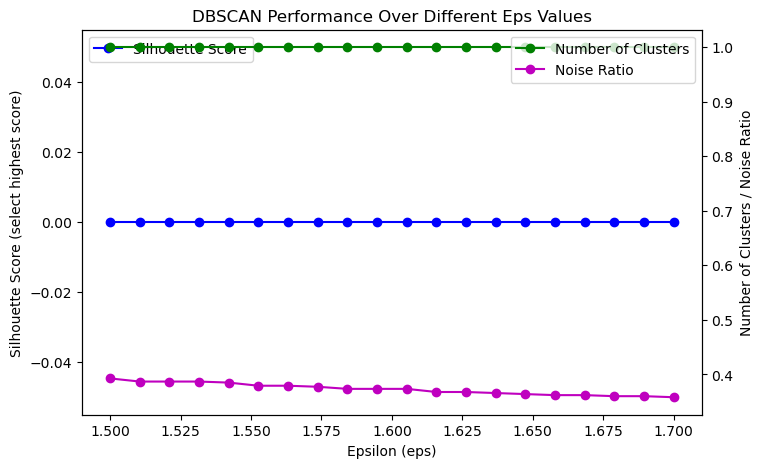

In [ ]:
graph_df = pd.read_csv(os.path.join(brighten_dir, f'{cluster_var}{n_clusters}_map.csv'))
dtw_matrix, embedding, results = cl.cluster_dtw_analysis(pivot_df, required_weeks, eps_values=np.linspace(1.5, 1.7, 20), min_samples=10, verbose=True)

In [ ]:
# ##### Cluster subjects into network subtypes
# #### Save each sub's V1 symptom correlation distance matrix into v1_symptom_matrices

# def flatten_matrix(corr_matrix):
#     indices = []
#     for i in range(corr_matrix.shape[0]):
#         for j in range(i, corr_matrix.shape[1]):
#             if not i==j:
#                 indices.append([i,j])
#     return [corr_matrix.iloc[row, col] for row, col in indices]

# def upper_triangle(corr_matrix):
#     indices = []
#     for i in range(corr_matrix.shape[0]):
#         for j in range(i, corr_matrix.shape[1]):
#             if not i==j:
#                 indices.append([i,j])
#     return indices

# for name, df in d
# #full_df_v1 = full_df_v1.drop(columns='aggregate_communication_scaled')
# subs = full_df_v1['num_id'].unique()
# print(f'In full_dt_v1 there are {len(subs)} subjects.')

# flattened_sub_matrices = {}
# v1_symptom_matrices = {}
# subs2 = []
# for sub in subs:
#     data = full_df_v1[full_df_v1['num_id']==sub] # filter for each specific sub
#     # keep only numerical/changing columns
#     keep_columns = [var for var in full_df_v1.columns.to_list() if var.startswith('pc_')]
#     data = data[keep_columns] 
#     # transform into correlation matrix
#     correlation_matrix = data.corr() 
#     # Replace inf/-inf with NaN
#     correlation_matrix = correlation_matrix.replace([float('inf'), -float('inf')], pd.NA)  
#     # drop resulting NaNs
#     correlation_matrix = correlation_matrix.dropna() 
#     # add subs with non-empty matrices to subs2
#     if not correlation_matrix.empty:
#         subs2.append(sub) 
#          # add entire corr matrix to list
#         v1_symptom_matrices[sub] = correlation_matrix
#         # extract unique values from upper triangle into vector
#         vector = flatten_matrix(correlation_matrix) 
#          # add nonzero vector to list
#         if not len(vector)==0:
#             flattened_sub_matrices[sub] = vector

#         # # Heatmap
#         # plt.figure(figsize=(2, 1))
#         # sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.1f', linewidths=0.5)
#         # plt.title(f"{sub}")
#         # plt.show()

#     #     # Line/Scatter plot
#     #     x = np.arange(len(vector))
#     #     plt.figure(figsize=(2, 1))
#     #     plt.scatter(x, vector, label="Points", color="blue")

    
# # plt.show()


# print(len(flattened_sub_matrices.keys()), 'filled arrays')


# linkage_matrix = linkage(list(flattened_sub_matrices.values()), method='ward', metric='euclidean')
# dendrogram(linkage_matrix, labels=list(flattened_sub_matrices.keys()))
# plt.show()



In [ ]:

# # Step 5: Perform clustering of subjects
# num_clusters = 5
# hierarchical_cluster = AgglomerativeClustering(
#     n_clusters=num_clusters,  # Number of clusters
#     linkage='ward'  # Linkage method
# )

# labels = hierarchical_cluster.fit_predict(linkage_matrix)
# print(labels)

# sub_clusters = dict(zip(flattened_sub_matrices.keys(), labels))